# LAPIS — Exploratory Data Analysis

**LAPIS** is an image-aesthetics dataset built on paintings / artworks. It couples
each image with three complementary layers of annotation:

| Layer | File(s) | What it holds |
|---|---|---|
| **Computational image attributes** | `ImgAttributes_LAPIS.csv` | 47 low-level visual / aesthetic features per image (contrast, entropy, complexity, symmetry, fractal dimension, colour statistics …) |
| **GIAA** — *Generic* Image Aesthetic Assessment | `LAPIS_GIAA_{Train,Val,Test}split.csv` | one row per image with the **aggregated** human aesthetic response (min / max / mean / std, number of raters) plus art metadata (artist, genre, style) |
| **PIAA** — *Personalized* Image Aesthetic Assessment | `LAPIS_PIAA.csv` | one row per **(participant, image)** rating, with the individual score, response time, and rater demographics |

This notebook answers three questions:

1. **What features does the dataset contain?** — a full data dictionary of every table.
2. **What are the correlations?** — internal correlations, and the headline question:
   *which image attributes track how much people aesthetically appreciate an image?*
3. **A full EDA** — distributions, data-quality issues, category effects, and rater
   demographics.

> Charts use a colour-blind-safe palette (blue↔red diverging for correlations, a
> single blue hue for magnitudes, fixed categorical hues for identity). No seaborn
> dependency — matplotlib only.

In [1]:
%matplotlib inline
import os, warnings
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from IPython.display import display

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

# --- colour-blind-safe palette (validated categorical set) -----------------
PALETTE = ["#2a78d6", "#1baf7a", "#eda100", "#008300",
           "#4a3aa7", "#e34948", "#e87ba4", "#eb6834"]
BLUE, AQUA, YELLOW, GREEN, VIOLET, RED, MAGENTA, ORANGE = PALETTE

# diverging blue <-> gray <-> red  (correlations / signed magnitudes)
DIVERGING  = LinearSegmentedColormap.from_list("lapis_div", ["#2a78d6", "#f0efec", "#e34948"])
# single-hue blue light -> dark  (sequential magnitude)
SEQUENTIAL = LinearSegmentedColormap.from_list("lapis_seq", ["#cde2fb", "#256abf", "#0d366b"])

mpl.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 110,
    "axes.prop_cycle": mpl.cycler(color=PALETTE),
    "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.6,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlesize": 11, "axes.titleweight": "bold",
    "figure.titleweight": "bold", "font.size": 10,
})
print("ready — pandas", pd.__version__, "| numpy", np.__version__, "| matplotlib", mpl.__version__)

ready — pandas 3.0.3 | numpy 2.4.6 | matplotlib 3.11.0


## Reusable plotting helpers

In [2]:
def corr_heatmap(corr, title="", figsize=(7, 6), annot=True, ax=None, fontsize=7):
    """Diverging (-1..+1) correlation heatmap with an optional per-cell annotation."""
    created = ax is None
    if created:
        fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(corr.values, cmap=DIVERGING, vmin=-1, vmax=1, aspect="auto")
    ax.set_xticks(range(corr.shape[1])); ax.set_xticklabels(corr.columns, rotation=90, fontsize=fontsize)
    ax.set_yticks(range(corr.shape[0])); ax.set_yticklabels(corr.index, fontsize=fontsize)
    ax.grid(False)
    if annot:
        for i in range(corr.shape[0]):
            for j in range(corr.shape[1]):
                v = corr.values[i, j]
                ax.text(j, i, f"{v:.2f}", ha="center", va="center",
                        color="white" if abs(v) > 0.55 else "#222", fontsize=fontsize)
    ax.set_title(title)
    cb = ax.figure.colorbar(im, ax=ax, fraction=0.046, pad=0.04); cb.set_label("Pearson r")
    if created:
        plt.tight_layout(); plt.show()
    return ax


def scatter_fit(x, y, ax, xlabel, ylabel, color=BLUE):
    """Scatter with an OLS line and the Pearson r in the title."""
    x = np.asarray(x, float); y = np.asarray(y, float)
    m = np.isfinite(x) & np.isfinite(y)
    ax.scatter(x[m], y[m], s=6, alpha=0.20, color=color, edgecolors="none")
    if m.sum() > 2:
        b, a = np.polyfit(x[m], y[m], 1)
        xs = np.linspace(x[m].min(), x[m].max(), 100)
        ax.plot(xs, b * xs + a, color=RED, lw=1.8)
        r = np.corrcoef(x[m], y[m])[0, 1]
        ax.set_title(f"{xlabel}  (r = {r:.2f})", fontsize=9)
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)


def cat_bar(series, ax, title, color=BLUE, top=8):
    """Horizontal count bar for a categorical column (top-N)."""
    vc = series.value_counts().head(top)[::-1]
    ax.barh(vc.index.astype(str), vc.values, color=color)
    ax.set_title(title); ax.grid(axis="y", alpha=0)
    for yi, v in enumerate(vc.values):
        ax.text(v, yi, f" {v:,}", va="center", fontsize=8)


def schema(df):
    """Compact data dictionary: dtype, unique count, missing, an example value."""
    return pd.DataFrame({
        "dtype":     df.dtypes.astype(str),
        "n_unique":  df.nunique(),
        "n_missing": df.isna().sum(),
        "example":   [df[c].dropna().iloc[0] if df[c].notna().any() else None for c in df.columns],
    })

## 1 · Load the data

LAPIS ships with **mixed encodings** — artist names in the attributes file use
Latin-1, so a naive `utf-8` read crashes. The loader below tries `utf-8` first and
falls back to `latin-1`. The three GIAA splits are concatenated into one frame with
a `split` label so we can analyse them together yet still tell them apart.

In [3]:
CANDIDATE_DIRS = [
    "../data/LAPIS github/annotation",
    "data/LAPIS github/annotation",
    "/shared/amin/code/playground/image-society/data/LAPIS github/annotation",
]
DATA_DIR = next((p for p in CANDIDATE_DIRS if os.path.isdir(p)), None)
assert DATA_DIR is not None, "Could not locate the LAPIS annotation directory."
print("DATA_DIR =", os.path.abspath(DATA_DIR))

def load_csv(name):
    path = os.path.join(DATA_DIR, name)
    for enc in ("utf-8", "latin-1"):
        try:
            return pd.read_csv(path, encoding=enc)
        except UnicodeDecodeError:
            continue
    return pd.read_csv(path, encoding="latin-1")

attr     = load_csv("ImgAttributes_LAPIS.csv")
giaa_tr  = load_csv("LAPIS_GIAA_Trainsplit.csv")
giaa_val = load_csv("LAPIS_GIAA_Valsplit.csv")
giaa_te  = load_csv("LAPIS_GIAA_Testsplit.csv")
piaa     = load_csv("LAPIS_PIAA.csv")

# drop the exported (unnamed) pandas index columns
for df in (attr, giaa_tr, giaa_val, giaa_te, piaa):
    df.drop(columns=[c for c in df.columns if str(c).startswith("Unnamed")],
            inplace=True, errors="ignore")

# one combined GIAA frame with a split label
giaa = pd.concat([giaa_tr.assign(split="train"),
                  giaa_val.assign(split="val"),
                  giaa_te.assign(split="test")], ignore_index=True)

for name, df in [("ImgAttributes", attr), ("GIAA train", giaa_tr), ("GIAA val", giaa_val),
                 ("GIAA test", giaa_te), ("GIAA combined", giaa), ("PIAA", piaa)]:
    print(f"{name:16s} rows={len(df):>7,}  cols={df.shape[1]}")

DATA_DIR = /shared/amin/code/playground/image-society/data/LAPIS github/annotation


ImgAttributes    rows= 11,724  cols=48
GIAA train       rows=  8,205  cols=14
GIAA val         rows=  1,173  cols=14
GIAA test        rows=  2,345  cols=14
GIAA combined    rows= 11,723  cols=15
PIAA             rows=283,860  cols=18


## 2 · How the tables relate

```
ImgAttributes_LAPIS         GIAA (train/val/test)              PIAA
   image_filename  ───┐      image_id / image_filename   ┌──   image_id / image_filename
   47 visual attrs    └────▶ min/max/mean/std_response ◀─┘      rating  (one per rater)
                             number of raters                  response time
                             artist, genre, style              participant demographics
```

* `image_filename` joins **attributes ↔ GIAA**.
* `image_id` / `image_filename` joins **GIAA ↔ PIAA**.
* GIAA is just PIAA aggregated per image (mean, std, count of the individual ratings).

In [4]:
overview = pd.DataFrame({
    "table":   ["ImgAttributes", "GIAA (train+val+test)", "PIAA"],
    "grain":   ["1 row / image", "1 row / image", "1 row / (participant, image) rating"],
    "rows":    [len(attr), len(giaa), len(piaa)],
    "columns": [attr.shape[1], giaa_tr.shape[1], piaa.shape[1]],
    "key(s)":  ["image_filename", "image_id / image_filename", "participant_id + image_id"],
})
display(overview)
print("unique images  — attr:", attr['image_filename'].nunique(),
      "| giaa:", giaa['image_filename'].nunique(),
      "| piaa:", piaa['image_id'].nunique())
print("unique raters  — piaa:", piaa['participant_id'].nunique())
print("avg ratings per image (piaa):", round(len(piaa) / piaa['image_id'].nunique(), 1))

,table,grain,rows,columns,key(s)
0,ImgAttributes,1 row / image,11724,48,image_filename
1,GIAA (train+val+test),1 row / image,11723,14,image_id / image_filename
2,PIAA,"1 row / (participant, image) rating",283860,18,participant_id + image_id


unique images  — attr: 11723 | giaa: 11723 | piaa: 11723
unique raters  — piaa: 568
avg ratings per image (piaa): 24.2


## 3 · What features does it have?

### 3a · The 47 computational image attributes

In [5]:
attr_cols = [c for c in attr.columns if c != "image_filename"]
print(f"{len(attr_cols)} image attributes:\n")
for i, c in enumerate(attr_cols, 1):
    print(f"{i:2d}. {c}")
display(attr[attr_cols].describe().T[["mean", "std", "min", "50%", "max"]])

47 image attributes:

 1. Image size (pixels)
 2. Aspect ratio
 3. RMS contrast
 4. Luminance entropy
 5. Complexity
 6. Edge density
 7. Color entropy
 8. mean R channel
 9. mean G channel
10. mean B channel (RGB)
11. mean L channel
12. mean a channel
13. mean b channel (Lab)
14. mean H channel
15. mean S channel
16. mean V channel
17. std R channel
18. std G channel
19. std B channel
20. std L channel
21. std a channel
22. std b channel (Lab)
23. std H channel
24. std S channel
25. std V channel
26. Mirror symmetry
27. DCM distance
28. DCM x position
29. DCM y position
30. Balance
31. CNN symmetry left-right
32. CNN symmetry up-down
33. CNN symmetry left-right & up-down
34. Slope Redies
35. Slope Spehar
36. Slope Mather
37. Fourier sigma
38. 2D Fractal dimension
39. 3D Fractal dimension
40. Self-similarity (PHOG)
41. Self-similarity (CNN)
42. Anisotropy
43. Homogeneity
44. 1st-order EOE
45. 2nd-order EOE
46. Sparseness
47. Variability


,mean,std,min,50%,max
Image size (pixels),"1,168.067",160.553,642.000,"1,189.000","1,499.000"
Aspect ratio,1.048,0.402,0.074,0.992,11.538
RMS contrast,19.161,6.872,0.708,19.293,48.243
Luminance entropy,6.906,0.844,1.394,7.164,7.965
Complexity,9.478,6.191,0.206,8.248,56.512
Edge density,86.968,48.497,2.480,79.472,523.382
Color entropy,5.303,1.308,0.000,5.473,7.902
mean R channel,137.496,44.932,10.684,136.614,253.131
mean G channel,124.342,44.272,10.849,122.269,248.350
mean B channel (RGB),107.910,46.420,2.068,102.743,248.818


### 3b · GIAA and PIAA data dictionaries

In [6]:
print("GIAA — one row per image (aggregated response + art metadata)")
display(schema(giaa_tr))
print("\nPIAA — one row per individual (participant, image) rating")
display(schema(piaa))

GIAA — one row per image (aggregated response + art metadata)


,dtype,n_unique,n_missing,example
image_id,int64,8205,0,4926
min_response,int64,63,0,0
max_response,int64,55,0,87
mean_response,float64,5806,0,41.552
std_response,float64,8169,0,26.438
number of raters,int64,45,0,29
image_filename,str,8205,0,boris-kustodiev_shells-1918.jpg
artist,str,784,0,boris-kustodiev
title,str,7785,0,shells-1918.jpg
genre,str,7,0,still life



PIAA — one row per individual (participant, image) rating


,dtype,n_unique,n_missing,example
image_id,int64,11723,0,3
image_filename,str,11723,0,aaron-siskind_new-york-2-1948.jpg
rating,int64,101,0,53
response time,int64,22075,0,2286
participant_id,int64,568,0,144
age,float64,54,17254,22.000
nationality,str,44,17254,british
demo_gender,str,4,17254,female
demo_edu,str,5,17254,secondary education
demo_colorblind,str,2,17254,No


## 4 · Data-quality checks

Three issues to be aware of before trusting any number:

1. **Blank row** — one row in the attributes file is entirely empty (no filename, no values); we drop it.
2. **Anonymous raters** — a block of PIAA ratings has *no* demographics at all (participants who skipped the survey).
3. **Corrupted `imgs_known`** — the "how many of these images do you know" field was mangled by Excel into date strings (`01-Oct`, `Nov-25`), so it is unusable and excluded.
4. **Response-time outliers** — response time spans from ~0.6 s to ~35 min (idle sessions); use a log scale.

In [7]:
n_blank = int(attr['image_filename'].isna().sum())
print("Fully-empty rows in ImgAttributes (no filename / no values):", n_blank)
attr = attr.dropna(subset=["image_filename"]).reset_index(drop=True)
print("attributes rows after cleaning:", len(attr))

miss = piaa.isna().mean().mul(100).round(1)
print("\nPIAA missingness (% of rows):")
display(miss[miss > 0].sort_values(ascending=False).to_frame("pct_missing"))

n_anon = int(piaa[["age", "nationality", "demo_gender"]].isna().all(axis=1).sum())
print(f"Ratings from participants with NO demographics: {n_anon:,} ({n_anon / len(piaa) * 100:.1f}%)")

print("\n'imgs_known' unique values (Excel-corrupted -> excluded):",
      list(piaa['imgs_known'].dropna().unique())[:6])

print("\nresponse time (ms) summary:")
display(piaa['response time'].describe(percentiles=[.5, .9, .99]).to_frame().T)

Fully-empty rows in ImgAttributes (no filename / no values): 1
attributes rows after cleaning: 11723

PIAA missingness (% of rows):


,pct_missing
imgs_known,23.100
nationality,6.100
age,6.100
demo_gender,6.100
demo_edu,6.100
demo_colorblind,6.100
Art Interest VAIAK,6.100


Ratings from participants with NO demographics: 17,254 (6.1%)

'imgs_known' unique values (Excel-corrupted -> excluded): ['01-Oct', 'more than 25', 'Nov-25']

response time (ms) summary:


,count,mean,std,min,50%,90%,99%,max
response time,"283,860.000","5,751.156","18,801.547",579.000,"3,638.000","8,949.000","33,937.640","2,094,871.000"


## 5 · GIAA — the aggregated aesthetic response

`mean_response` is the crowd's average aesthetic score for an image (0–100).
`std_response` measures how much raters **disagreed** — and it is large, which is
exactly what motivates the *personalized* PIAA layer.

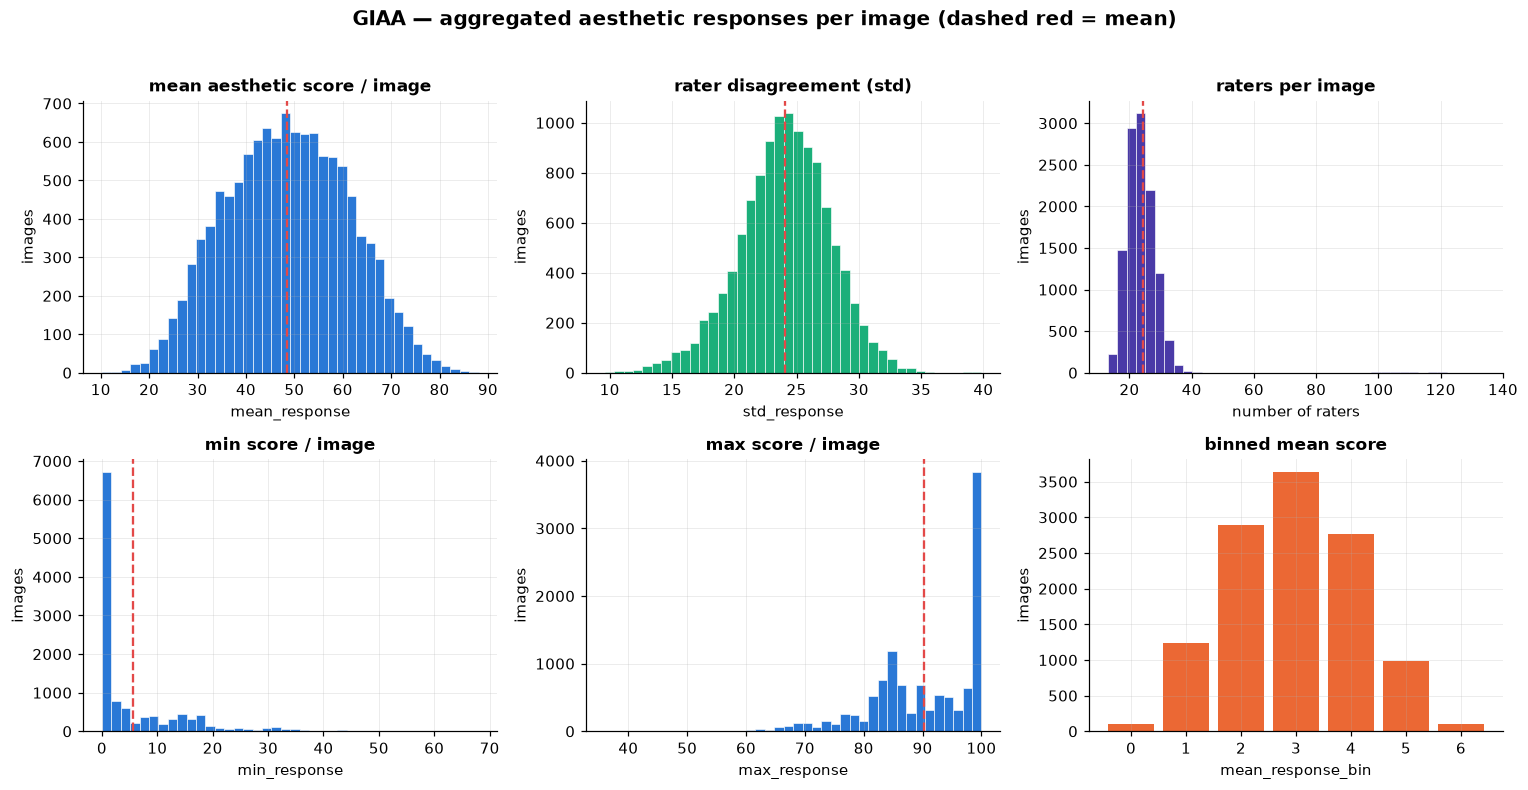

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
specs = [("mean_response", "mean aesthetic score / image", BLUE),
         ("std_response",  "rater disagreement (std)",     AQUA),
         ("number of raters", "raters per image",          VIOLET),
         ("min_response",  "min score / image",            BLUE),
         ("max_response",  "max score / image",            BLUE),
         ("mean_response_bin", "binned mean score",        ORANGE)]
for ax, (col, label, color) in zip(axes.ravel(), specs):
    data = giaa[col].dropna()
    if col == "mean_response_bin":
        vc = data.value_counts().sort_index()
        ax.bar(vc.index, vc.values, color=color, width=0.85)
    else:
        ax.hist(data, bins=40, color=color, edgecolor="white", linewidth=0.4)
        ax.axvline(data.mean(), color=RED, ls="--", lw=1.5)
    ax.set_title(label); ax.set_xlabel(col); ax.set_ylabel("images")
fig.suptitle("GIAA — aggregated aesthetic responses per image (dashed red = mean)", y=1.02, fontsize=13)
plt.tight_layout(); plt.show()

### 5a · Does aesthetic appreciation depend on genre / style?

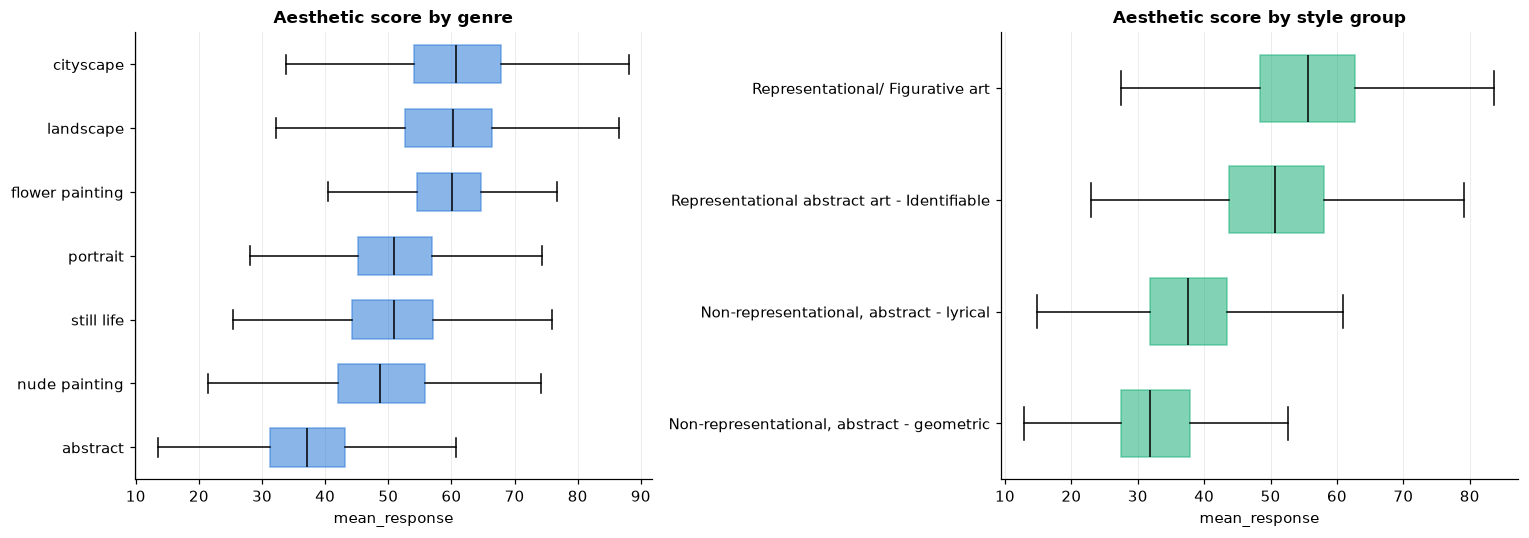

Mean score, figurative vs abstract:


,mean,std,count
2_styles,,,
ABSTRACT,37.164,8.735,3747
FIGURATIVE,53.933,10.543,7976


In [9]:
def grouped_box(df, cat, val, ax, color=BLUE):
    order = df.groupby(cat)[val].median().sort_values().index.tolist()
    data  = [df.loc[df[cat] == k, val].dropna().values for k in order]
    bp = ax.boxplot(data, vert=False, patch_artist=True, widths=0.6, showfliers=False)
    for patch in bp["boxes"]:
        patch.set_facecolor(color); patch.set_alpha(0.55); patch.set_edgecolor(color)
    for med in bp["medians"]:
        med.set_color("black")
    ax.set_yticklabels(order); ax.set_xlabel(val); ax.grid(axis="y", alpha=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
grouped_box(giaa, "genre", "mean_response", axes[0], BLUE)
axes[0].set_title("Aesthetic score by genre")
grouped_box(giaa, "4_styles", "mean_response", axes[1], AQUA)
axes[1].set_title("Aesthetic score by style group")
plt.tight_layout(); plt.show()

print("Mean score, figurative vs abstract:")
display(giaa.groupby("2_styles")["mean_response"].agg(["mean", "std", "count"]))

### 5b · Correlation among the GIAA response aggregates

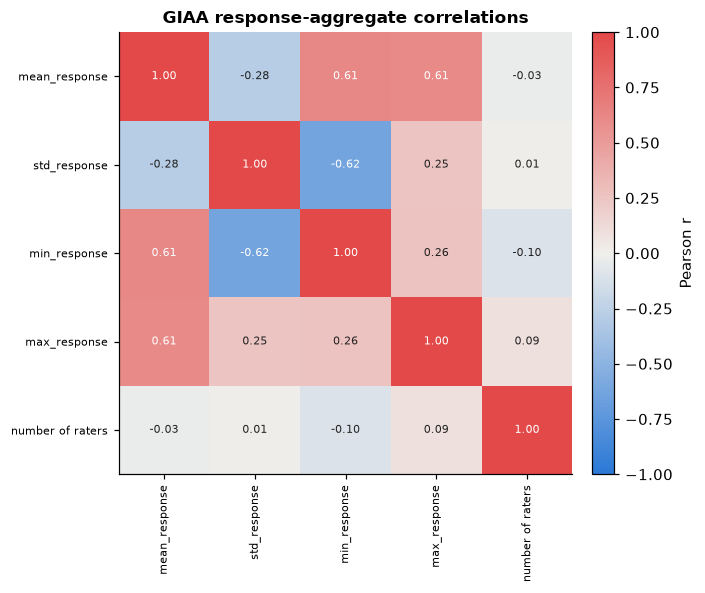

<Axes: title={'center': 'GIAA response-aggregate correlations'}>

In [10]:
resp_cols = ["mean_response", "std_response", "min_response", "max_response", "number of raters"]
corr_heatmap(giaa[resp_cols].corr(), "GIAA response-aggregate correlations", figsize=(6.5, 5.5))

## 6 · The image attributes — distributions and internal correlation

Many of these 47 features are engineered to capture the same underlying property
(e.g. several symmetry or self-similarity measures), so we expect strong
**collinearity** — worth knowing before feeding them to any model.

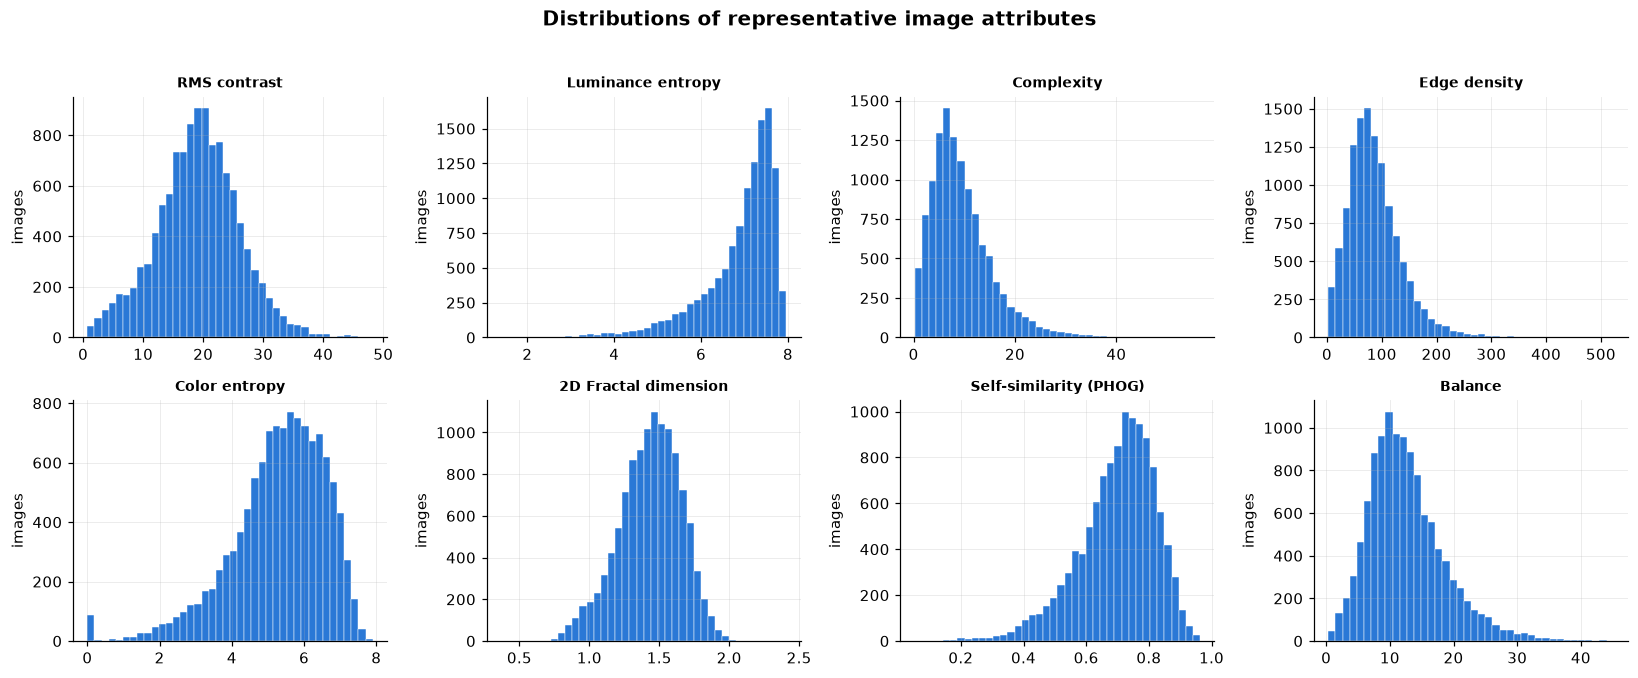

In [11]:
show = ["RMS contrast", "Luminance entropy", "Complexity", "Edge density",
        "Color entropy", "2D Fractal dimension", "Self-similarity (PHOG)", "Balance"]
show = [c for c in show if c in attr.columns]
fig, axes = plt.subplots(2, 4, figsize=(15, 6))
for ax, c in zip(axes.ravel(), show):
    ax.hist(attr[c].dropna(), bins=40, color=BLUE, edgecolor="white", linewidth=0.3)
    ax.set_title(c, fontsize=9); ax.set_ylabel("images")
fig.suptitle("Distributions of representative image attributes", y=1.02, fontsize=13)
plt.tight_layout(); plt.show()

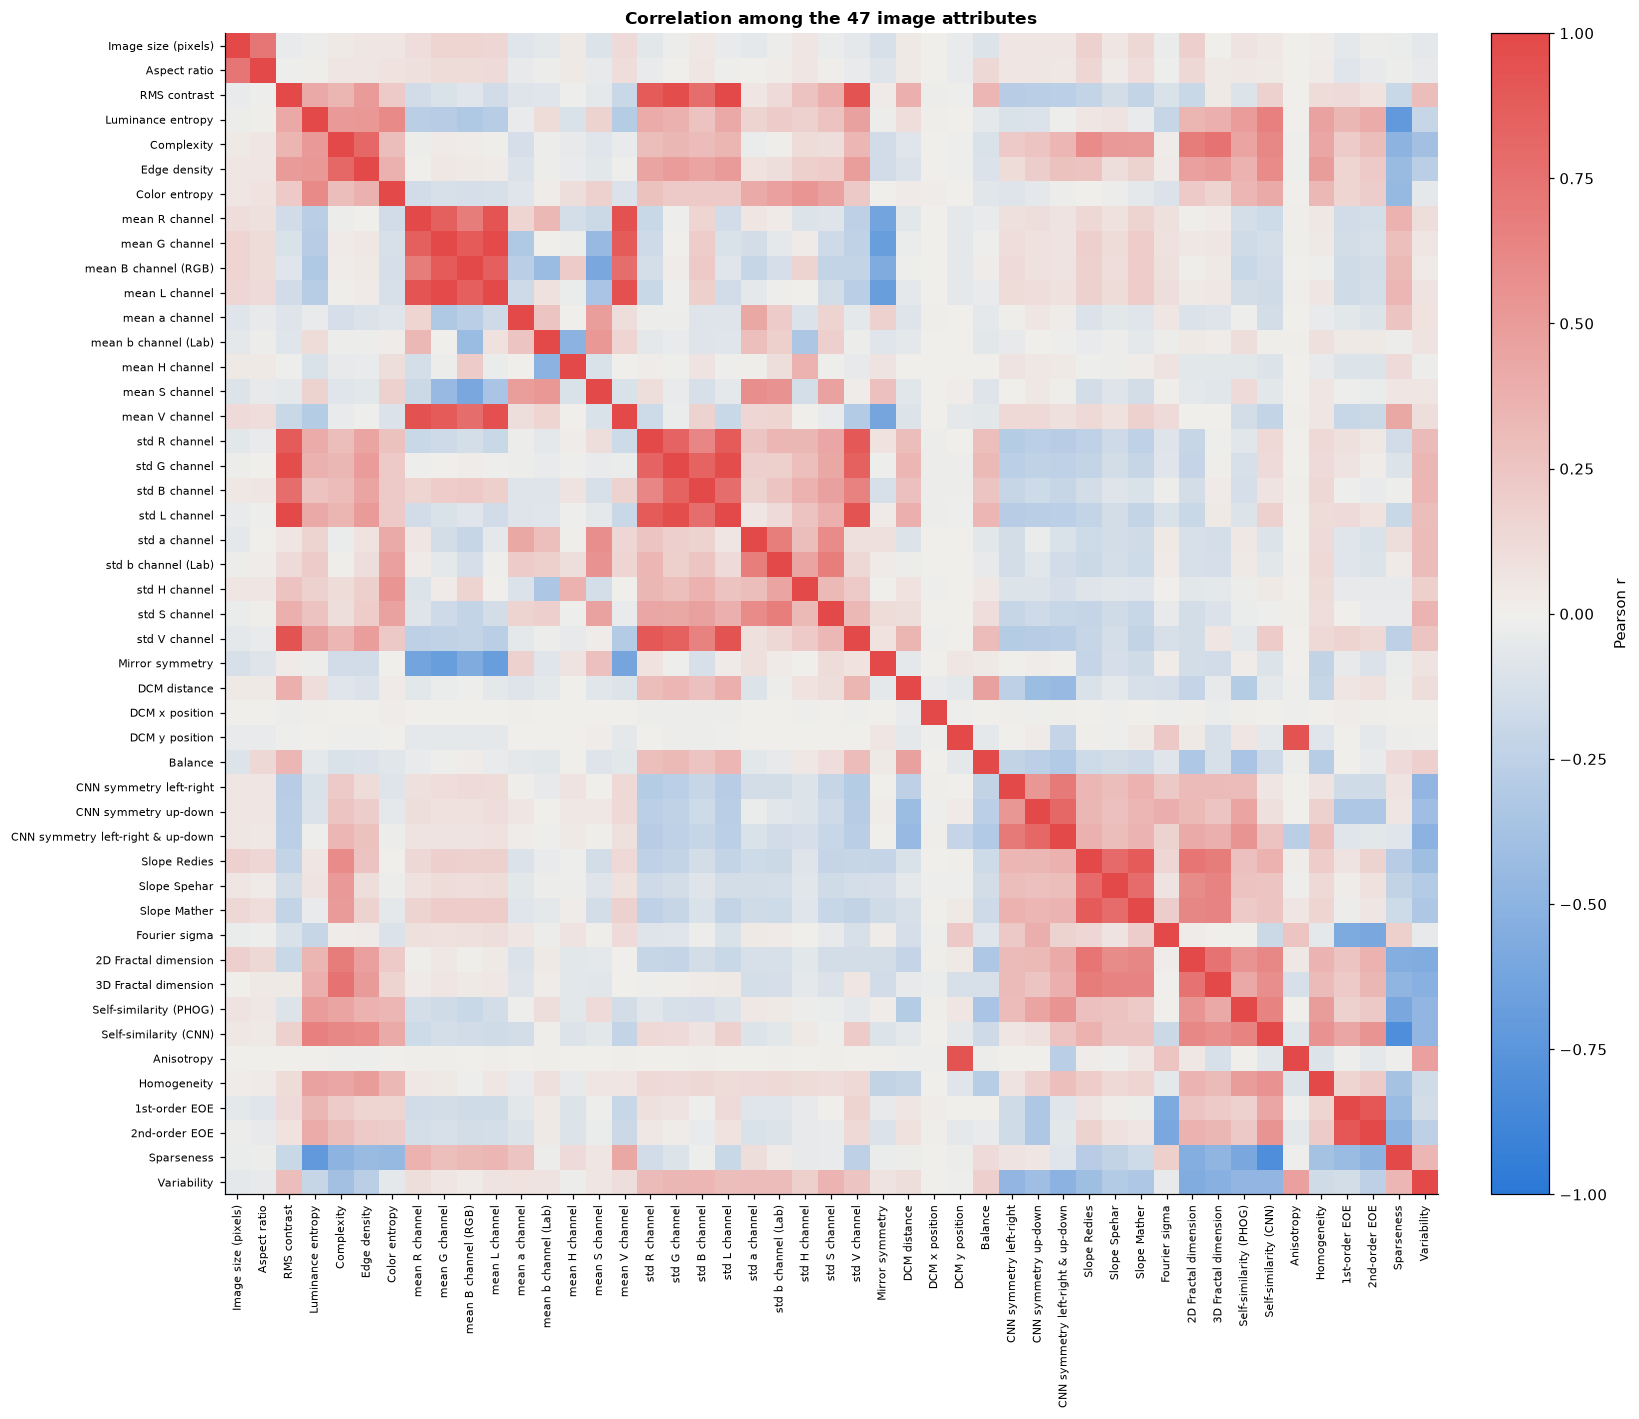

In [12]:
attr_corr = attr[attr_cols].corr()
fig, ax = plt.subplots(figsize=(15, 13))
corr_heatmap(attr_corr, "Correlation among the 47 image attributes", annot=False, ax=ax, fontsize=7)
plt.tight_layout(); plt.show()

**Strongest attribute-attribute pairs** (the collinear clusters):

In [13]:
c = attr_corr.where(~np.eye(len(attr_corr), dtype=bool))
stacked = c.abs().stack().sort_values(ascending=False)
seen, rows = set(), []
for (a, b), _ in stacked.items():
    key = frozenset((a, b))
    if key in seen:
        continue
    seen.add(key); rows.append((a, b, round(float(attr_corr.loc[a, b]), 3)))
    if len(rows) >= 12:
        break
display(pd.DataFrame(rows, columns=["attribute_1", "attribute_2", "pearson_r"]))

,attribute_1,attribute_2,pearson_r
0,RMS contrast,std L channel,1.000
1,mean L channel,mean G channel,0.985
2,RMS contrast,std G channel,0.966
3,std G channel,std L channel,0.966
4,mean V channel,mean L channel,0.950
5,mean R channel,mean V channel,0.941
6,std V channel,std L channel,0.937
7,std V channel,RMS contrast,0.937
8,Anisotropy,DCM y position,0.934
9,mean L channel,mean R channel,0.924


## 7 ·  ★ Headline correlation: which attributes track aesthetic appreciation?

Join the image attributes to each image's crowd-mean aesthetic score and rank every
attribute by its Pearson correlation with `mean_response`. Positive (blue) = the
feature goes **up** with liking; negative (red) = it goes **down**.

images with both attributes and a GIAA score: 11723


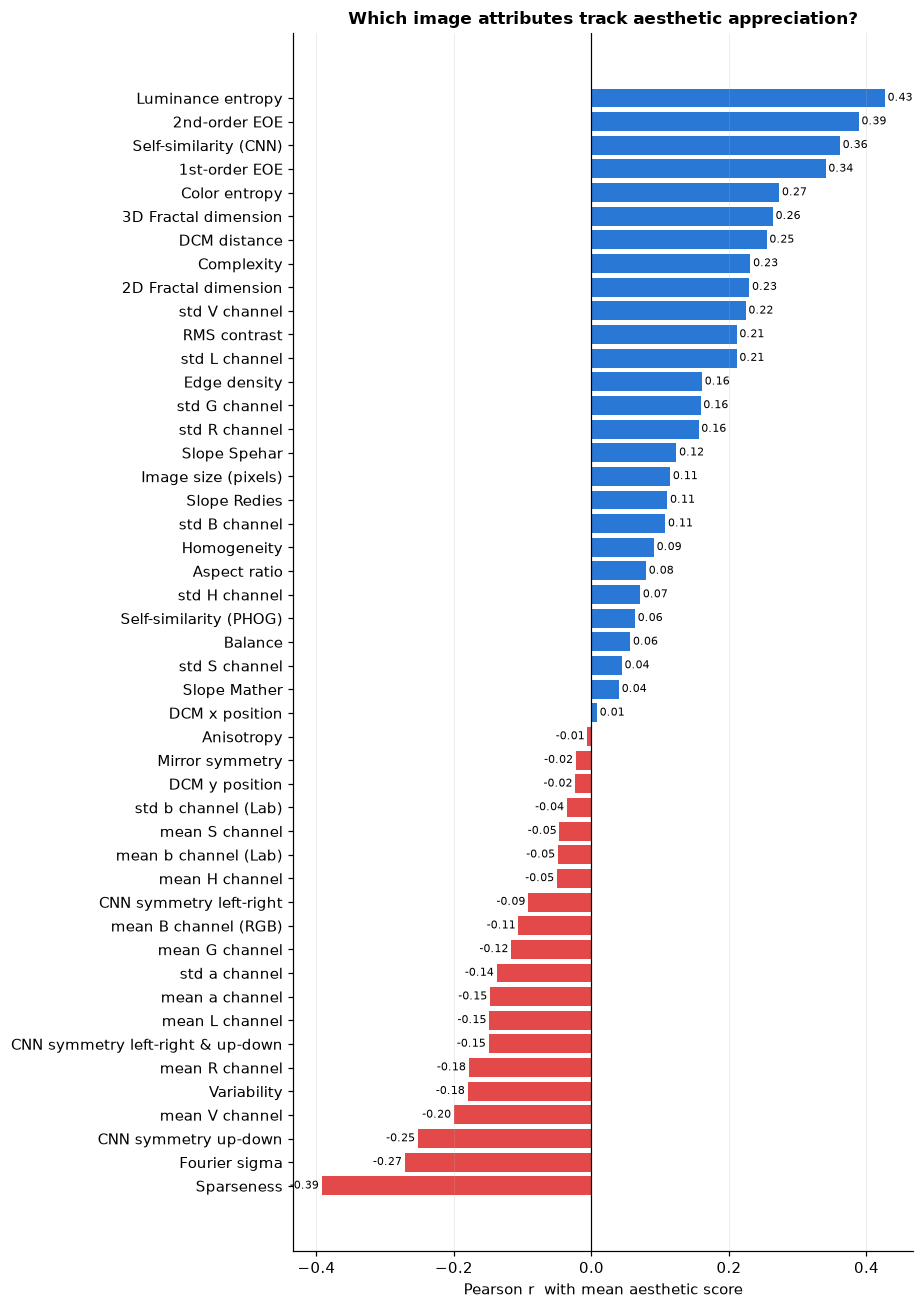

In [14]:
img = giaa.drop_duplicates("image_filename").merge(attr, on="image_filename", how="inner")
print("images with both attributes and a GIAA score:", len(img))

corr_resp = (img[attr_cols + ["mean_response"]].corr()["mean_response"]
             .drop("mean_response").sort_values())

fig, ax = plt.subplots(figsize=(8.5, 12))
colors = [BLUE if v >= 0 else RED for v in corr_resp.values]
ax.barh(corr_resp.index, corr_resp.values, color=colors)
ax.axvline(0, color="black", lw=0.8); ax.grid(axis="y", alpha=0)
ax.set_xlabel("Pearson r  with mean aesthetic score")
ax.set_title("Which image attributes track aesthetic appreciation?")
for yi, v in enumerate(corr_resp.values):
    ax.text(v + (0.004 if v >= 0 else -0.004), yi, f"{v:.2f}",
            va="center", ha="left" if v >= 0 else "right", fontsize=7)
plt.tight_layout(); plt.show()

The strongest relationships, shown directly (OLS fit + Pearson r):

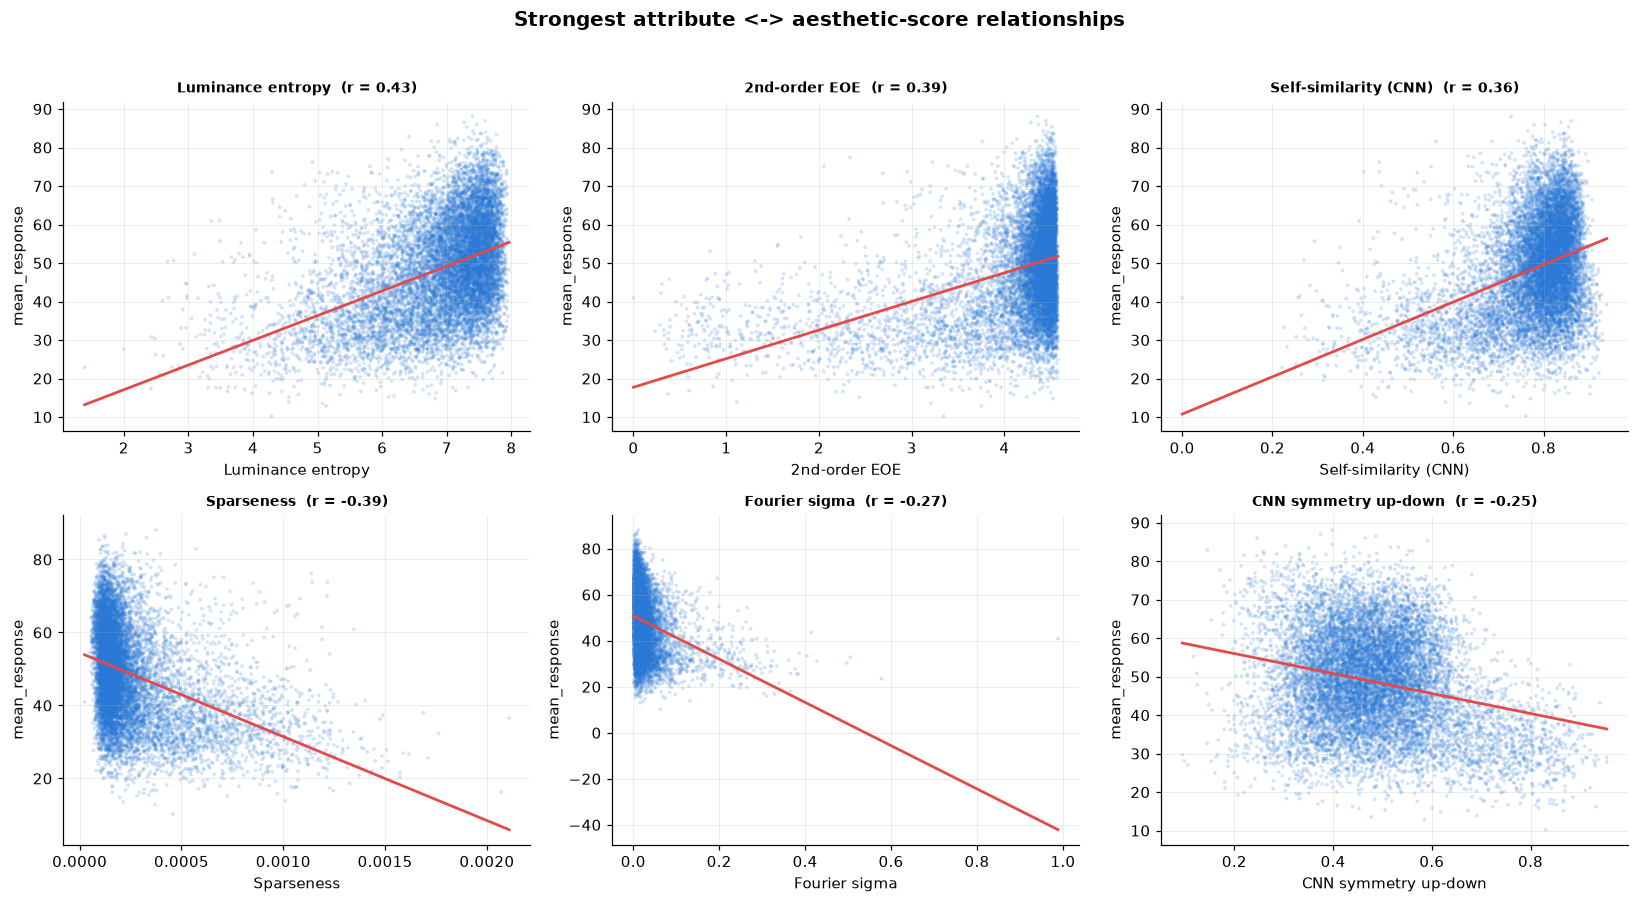

In [15]:
top_pos = list(corr_resp.index[-3:][::-1])
top_neg = list(corr_resp.index[:3])
sel = top_pos + top_neg
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.ravel(), sel):
    scatter_fit(img[col].values, img["mean_response"].values, ax, col, "mean_response")
fig.suptitle("Strongest attribute <-> aesthetic-score relationships", y=1.02, fontsize=13)
plt.tight_layout(); plt.show()

## 8 · PIAA — individual ratings and rater demographics

The personalized layer is where LAPIS is distinctive: 283k individual ratings let us
look at **who** is rating and how much raters differ from each other and from the crowd.

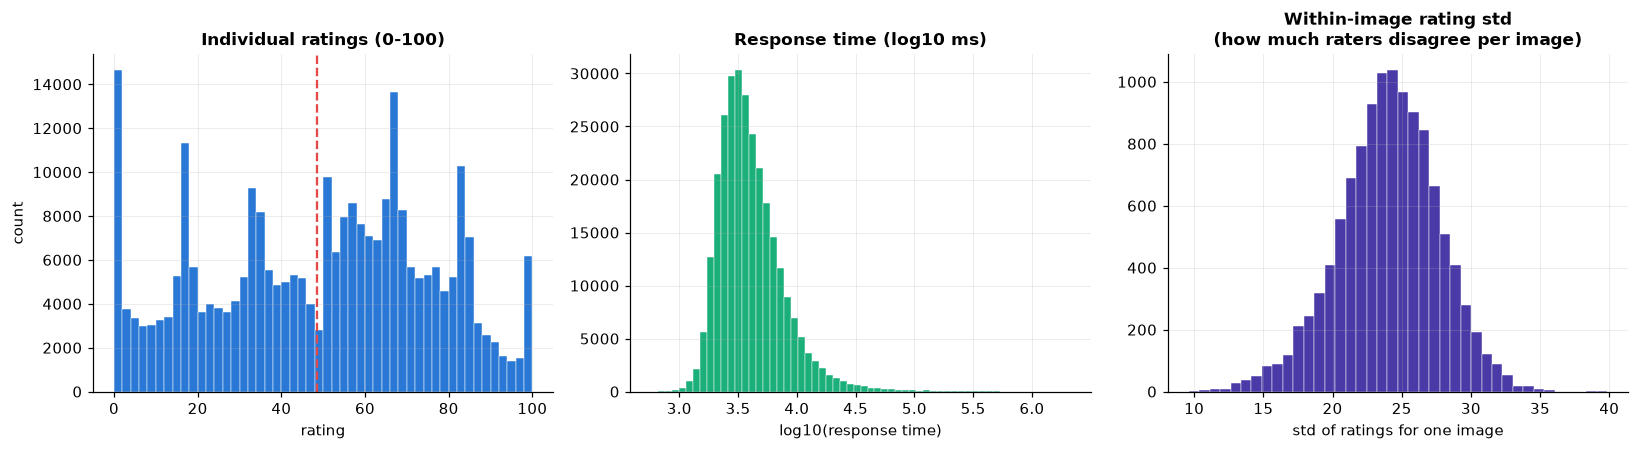

median response time (ms): 3638 | median within-image std: 24.2


In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
axes[0].hist(piaa["rating"], bins=50, color=BLUE, edgecolor="white", linewidth=0.3)
axes[0].axvline(piaa["rating"].mean(), color=RED, ls="--", lw=1.5)
axes[0].set_title("Individual ratings (0-100)"); axes[0].set_xlabel("rating"); axes[0].set_ylabel("count")

rt = piaa["response time"].clip(lower=1)
axes[1].hist(np.log10(rt), bins=60, color=AQUA, edgecolor="white", linewidth=0.3)
axes[1].set_title("Response time (log10 ms)"); axes[1].set_xlabel("log10(response time)")

per_img_std = piaa.groupby("image_id")["rating"].std()
axes[2].hist(per_img_std.dropna(), bins=40, color=VIOLET, edgecolor="white", linewidth=0.3)
axes[2].set_title("Within-image rating std\n(how much raters disagree per image)")
axes[2].set_xlabel("std of ratings for one image")
plt.tight_layout(); plt.show()
print("median response time (ms):", int(piaa['response time'].median()),
      "| median within-image std:", round(float(per_img_std.median()), 1))

### 8a · Who are the raters? (each rating carries its rater's demographics)

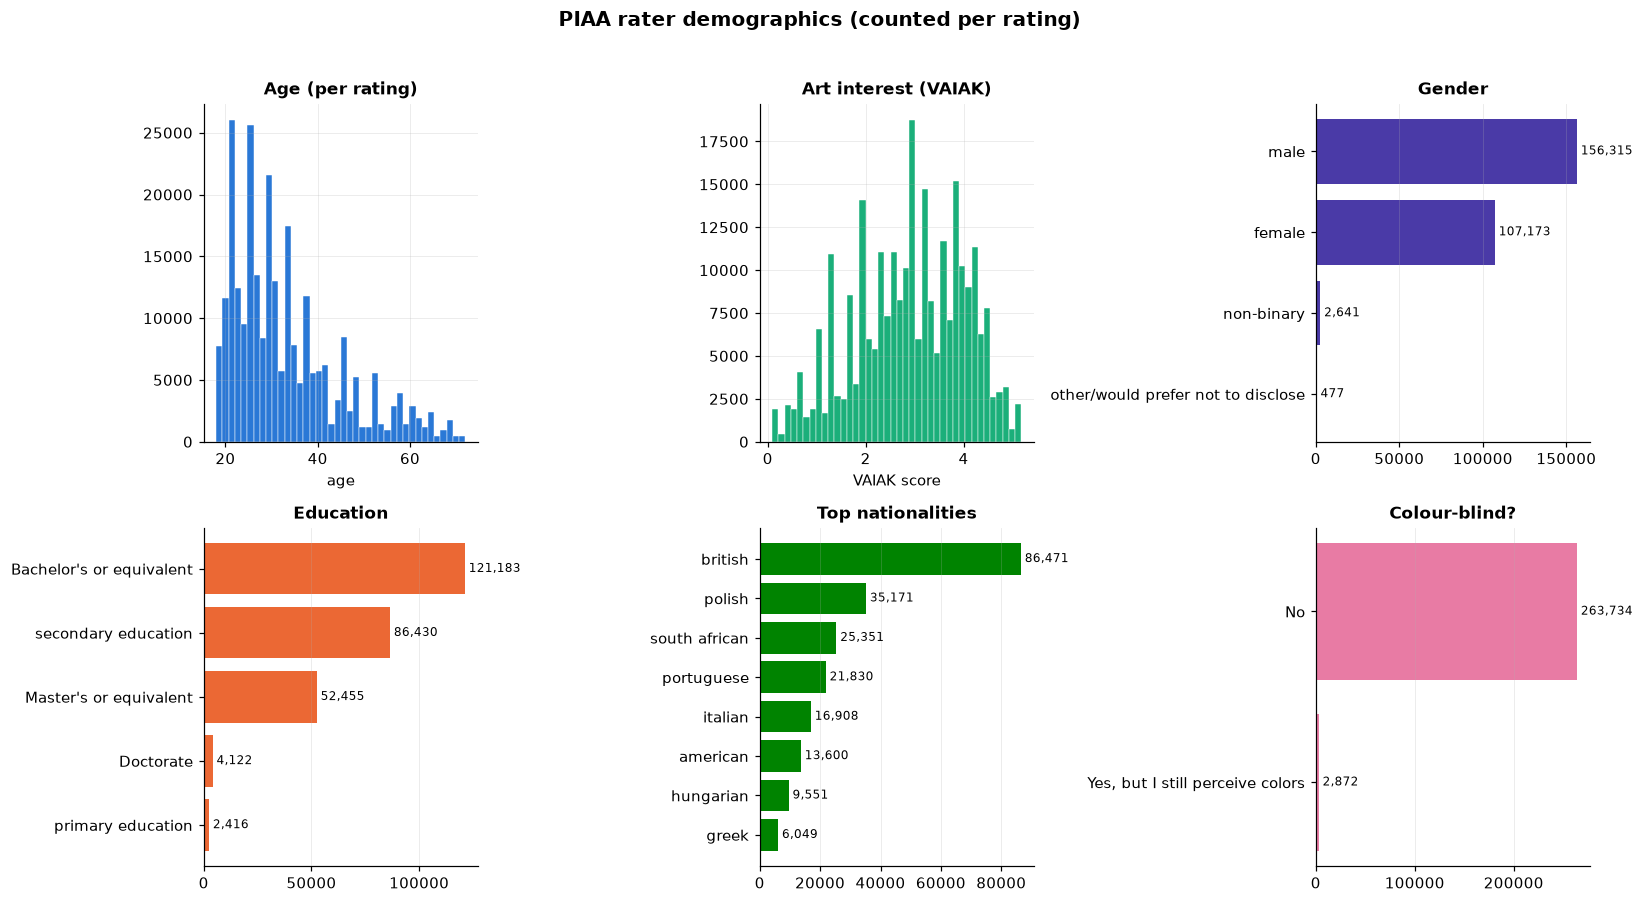

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes[0, 0].hist(piaa["age"].dropna(), bins=40, color=BLUE, edgecolor="white", linewidth=0.3)
axes[0, 0].set_title("Age (per rating)"); axes[0, 0].set_xlabel("age")
axes[0, 1].hist(piaa["Art Interest VAIAK"].dropna(), bins=40, color=AQUA, edgecolor="white", linewidth=0.3)
axes[0, 1].set_title("Art interest (VAIAK)"); axes[0, 1].set_xlabel("VAIAK score")
cat_bar(piaa["demo_gender"],     axes[0, 2], "Gender",            VIOLET)
cat_bar(piaa["demo_edu"],        axes[1, 0], "Education",         ORANGE)
cat_bar(piaa["nationality"],     axes[1, 1], "Top nationalities", GREEN)
cat_bar(piaa["demo_colorblind"], axes[1, 2], "Colour-blind?",     MAGENTA)
fig.suptitle("PIAA rater demographics (counted per rating)", y=1.02, fontsize=13)
plt.tight_layout(); plt.show()

### 8b · Rater effects — do demographics move the rating?

Aggregate to **one row per participant** (568 raters) so each person counts once, then
relate their mean rating to age and art interest. The wide spread of per-participant
mean ratings is *rater leniency* — a core reason generic scores are not enough.

participants: 568


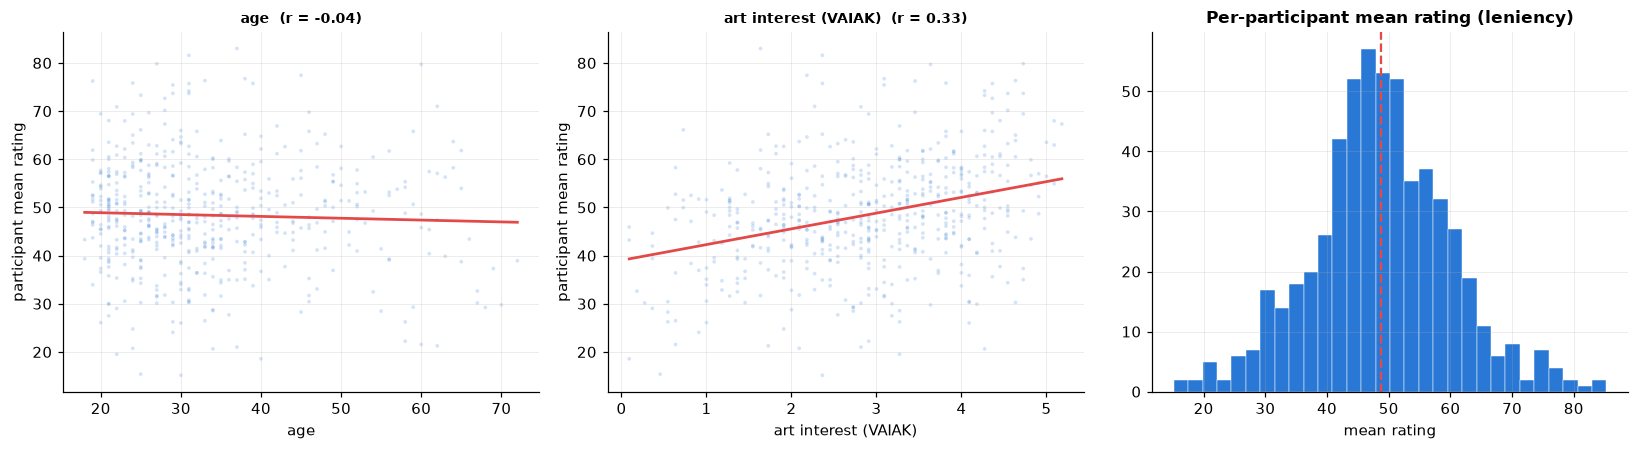

In [18]:
part = piaa.groupby("participant_id").agg(
    n_ratings=("rating", "size"),
    mean_rating=("rating", "mean"),
    age=("age", "first"),
    art_interest=("Art Interest VAIAK", "first"),
    gender=("demo_gender", "first"),
    edu=("demo_edu", "first"),
).reset_index()
print("participants:", len(part))

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
scatter_fit(part["age"], part["mean_rating"], axes[0], "age", "participant mean rating")
scatter_fit(part["art_interest"], part["mean_rating"], axes[1], "art interest (VAIAK)", "participant mean rating")
axes[2].hist(part["mean_rating"].dropna(), bins=30, color=BLUE, edgecolor="white", linewidth=0.3)
axes[2].axvline(part["mean_rating"].mean(), color=RED, ls="--", lw=1.5)
axes[2].set_title("Per-participant mean rating (leniency)"); axes[2].set_xlabel("mean rating")
plt.tight_layout(); plt.show()

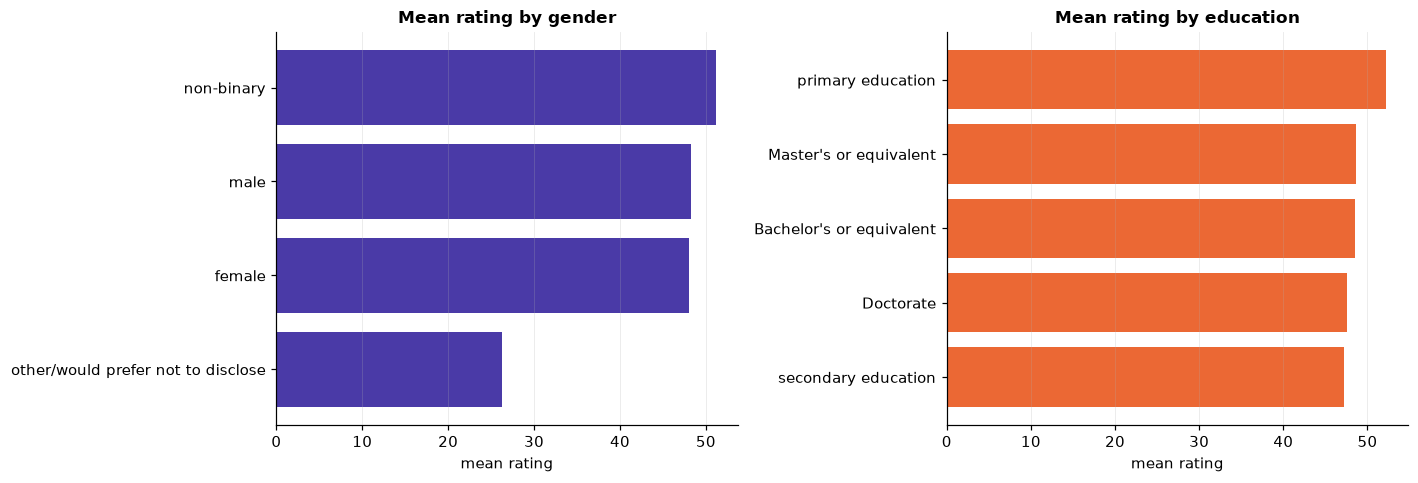

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
g = piaa.groupby("demo_gender")["rating"].mean().sort_values()
axes[0].barh(g.index.astype(str), g.values, color=VIOLET); axes[0].grid(axis="y", alpha=0)
axes[0].set_title("Mean rating by gender"); axes[0].set_xlabel("mean rating")
e = piaa.groupby("demo_edu")["rating"].mean().sort_values()
axes[1].barh(e.index.astype(str), e.values, color=ORANGE); axes[1].grid(axis="y", alpha=0)
axes[1].set_title("Mean rating by education"); axes[1].set_xlabel("mean rating")
plt.tight_layout(); plt.show()

## 9 · Key numbers

In [20]:
print("Top 5 attributes POSITIVELY correlated with aesthetic score:")
display(corr_resp.tail(5)[::-1].to_frame("pearson_r"))
print("Top 5 attributes NEGATIVELY correlated with aesthetic score:")
display(corr_resp.head(5).to_frame("pearson_r"))

age_m = part.dropna(subset=["age"])
ai_m  = part.dropna(subset=["art_interest"])
print("age vs participant mean rating         r =",
      round(float(np.corrcoef(age_m["age"], age_m["mean_rating"])[0, 1]), 3))
print("art interest vs participant mean rating r =",
      round(float(np.corrcoef(ai_m["art_interest"], ai_m["mean_rating"])[0, 1]), 3))
print("largest |attribute r| with mean_response:",
      round(float(corr_resp.abs().max()), 3), "->", corr_resp.abs().idxmax())

Top 5 attributes POSITIVELY correlated with aesthetic score:


,pearson_r
Luminance entropy,0.427
2nd-order EOE,0.389
Self-similarity (CNN),0.361
1st-order EOE,0.341
Color entropy,0.273


Top 5 attributes NEGATIVELY correlated with aesthetic score:


,pearson_r
Sparseness,-0.392
Fourier sigma,-0.272
CNN symmetry up-down,-0.252
mean V channel,-0.200
Variability,-0.180


age vs participant mean rating         r = -0.039
art interest vs participant mean rating r = 0.329
largest |attribute r| with mean_response: 0.427 -> Luminance entropy


## 10 · Summary of findings

**Structure.** LAPIS links ~11.7k painting images across three tables: 47 computational
image attributes, GIAA crowd-aggregated aesthetic scores (train/val/test), and 283.9k
individual PIAA ratings from 568 participants (~24 ratings per image).

**Aesthetic response (GIAA).** Mean scores are broadly unimodal and centred near the
middle of the 0–100 range. Crucially, `std_response` is large — raters disagree a lot
about the *same* image — which is the empirical motivation for personalized modelling.
Aesthetic appreciation shifts with genre and figurative-vs-abstract style (see §5a).

**Image attributes (§6).** The 47 features are heavily collinear — several
symmetry, self-similarity and colour-channel measures are near-duplicates
(|r| > 0.9) — so any downstream model should de-correlate / select features first.

**Headline correlation (§7).** Individual low-level attributes correlate only *weakly*
with crowd aesthetic appreciation (the strongest |r| is modest, printed in §9): beauty
is not captured by any single hand-crafted feature, which is why the field moved to
learned VLM-based aesthetic models. The signed ranking still shows the *direction* of
each feature's effect.

**Raters (§8).** The rater pool skews toward British / Polish / South-African, mostly
20–40 y old, majority Bachelor's-educated. Per-participant mean ratings vary widely
(rater leniency); age and art-interest have only mild associations with how high people
score on average.

**Data-quality caveats.** One fully-empty attribute row (dropped), a block of
demographic-free "anonymous" ratings (~6% of ratings), and an unusable
Excel-corrupted `imgs_known` column — handled/flagged in §4.